In [19]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh

# ======================
# 参数
# ======================
dela = 1
t = 38 * dela
af = 400/0.1875 * dela * 1e-10
a = 1e-10*(0.001)
mu =7 * dela
U = 1.9 * dela
mz = 7 * dela
h = 1.2 * np.sqrt(mu**2 + dela**2)

chaodaojiao = 0   # 超导相位差

# ======================
# Pauli matrices
# ======================
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.eye(2, dtype=complex)

# ======================
# BdG blocks
# ======================
def bdg_onsite(mu, hx, hy, Delta):
    H = -(mu - 2*t) * s0 + hx * sx + hy * sy
    return np.block([
        [ H,              Delta ],
        [ Delta.conj().T, -H.conj() ]
    ])

def bdg_hop():
    hop = -(t * s0 + 1j * af/a * sz)
    return np.block([
        [ hop,               np.zeros((2,2)) ],
        [ np.zeros((2,2)),  -hop.conj() ]
    ])

lat = kwant.lattice.chain(norbs=4)

# ======================
# 构造系统
# ======================
def make_system(L=11):

    syst = kwant.Builder()

    # -------- 中间区域 --------
    for i in range(L):
        Hc = (U - mu + 2*t) * s0 + mz * sz
        onsite = np.block([
            [ Hc,              np.zeros((2,2)) ],
            [ np.zeros((2,2)), -Hc.conj() ]
        ])
        syst[lat(i)] = onsite

        if i > 0:
            syst[lat(i), lat(i-1)] = np.block([
                [ -t*s0,           np.zeros((2,2)) ],
                [ np.zeros((2,2)),  t*s0 ]
            ])

    # -------- 左超导 lead --------
    leadL = kwant.Builder(kwant.TranslationalSymmetry((-1,)))

    Delta_L = dela * np.exp(1j * chaodaojiao/2) * 1j * sy
    leadL[lat(0)] = bdg_onsite(mu, h, 0, Delta_L)
    leadL[lat(0), lat(-1)] = bdg_hop()

    # -------- 右超导 lead --------
    leadR = kwant.Builder(kwant.TranslationalSymmetry((1,)))

    def onsite_R(site, saimanjiao):
        Delta_R = dela * np.exp(-1j * chaodaojiao/2) * 1j * sy
        return bdg_onsite(
            mu,
            h * np.cos(saimanjiao),
            h * np.sin(saimanjiao),
            Delta_R
        )

    leadR[lat(0)] = onsite_R
    leadR[lat(0), lat(1)] = bdg_hop()

    # -------- 接导线 --------
    syst.attach_lead(leadL)
    syst.attach_lead(leadR)

    return syst


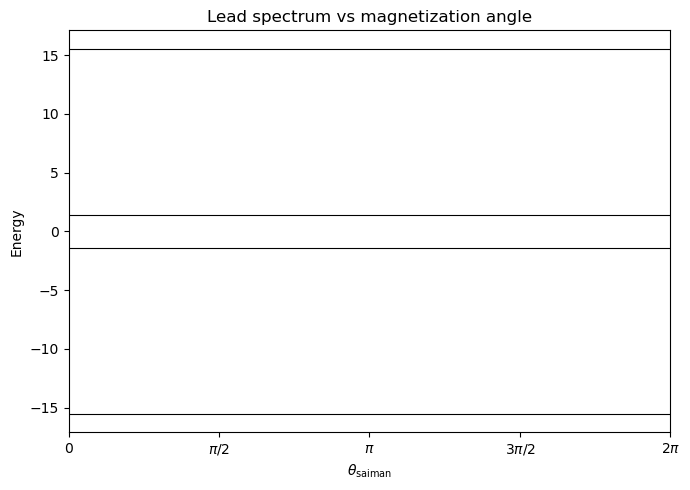

In [20]:
num_points = 400
saimanjiao_array = np.linspace(0, 2*np.pi, num_points)
k = np.linspace(-np.pi, np.pi, 200)
syst = make_system()
fsyst = syst.finalized()

lead = fsyst.leads[1]   # 右导线（有 saimanjiao）

energies_vs_theta = []

for theta in saimanjiao_array:
    bands = kwant.physics.Bands(lead, params=dict(saimanjiao=theta))
    energies_vs_theta.append(bands(0))   # k = 0

energies_vs_theta = np.array(energies_vs_theta)
plt.figure(figsize=(7,5))

for n in range(energies_vs_theta.shape[1]):
    plt.plot(
        saimanjiao_array,
        energies_vs_theta[:, n],
        'k-', lw=0.8
    )

plt.xlabel(r'$\theta_{\mathrm{saiman}}$')
plt.ylabel('Energy')
plt.xlim(0, 2*np.pi)

plt.xticks(
    [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
    ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']
)

plt.title('Lead spectrum vs magnetization angle')
plt.tight_layout()
plt.show()



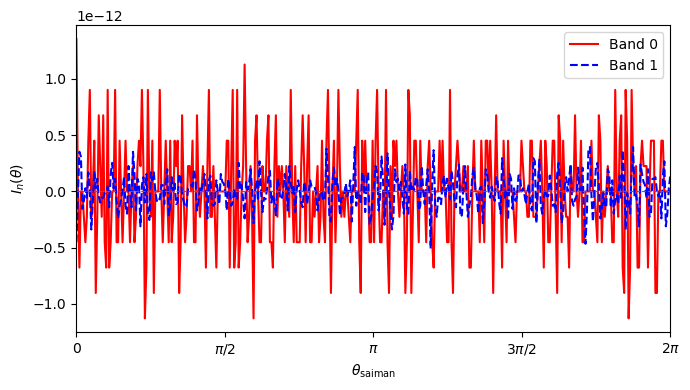

In [12]:
syst = make_system()
fsyst = syst.finalized()

lead = fsyst.leads[1]   # 含 saimanjiao 的那根导线

E0 = []
E1 = []

for theta in saimanjiao_array:
    bands = kwant.physics.Bands(
        lead,
        params=dict(saimanjiao=theta)
    )

    E = np.sort(bands(0))   # k = 0，排序
    E0.append(E[0])
    E1.append(E[1])

E0 = np.array(E0)
E1 = np.array(E1)
e = 1.0
hbar = 1.0

dtheta = saimanjiao_array[1] - saimanjiao_array[0]

I0 = 2 * e / hbar * np.gradient(E0, dtheta)
I1 = 2 * e / hbar * np.gradient(E1, dtheta)
plt.figure(figsize=(7,4))

plt.plot(saimanjiao_array, I0, 'r-', lw=1.5, label='Band 0')
plt.plot(saimanjiao_array, I1, 'b--', lw=1.5, label='Band 1')

plt.xlabel(r'$\theta_{\mathrm{saiman}}$')
plt.ylabel(r'$I_n(\theta)$')
plt.xlim(0, 2*np.pi)
plt.axhline(0, ls='--', lw=0.8)

plt.xticks(
    [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
    ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']
)

plt.legend()
plt.tight_layout()
plt.show()


